In [281]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [282]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import linalg as la
from tqdm import trange
from dataclasses import dataclass, field

from pachner_metropolis_functions import (
    lattice_squenergy,
    boltzmann_probability,
    choose_flip,
    n_squares,
)

from koala.flux_finder import ujk_from_fluxes, fluxes_from_ujk
import mpmath
from dimer_models.kasteleyn import kasteleyn_matrix, fast_pfaffian_as_mpmath
from koala.pointsets import uniform
from koala.voronization import generate_lattice
from koala import graph_utils as gu
from koala import plotting as pl
from koala.lattice import Lattice, INVALID
from koala import example_graphs as eg
from koala import pachner_moves

# mpmath.mp.dps = 50
import pickle

from dimer_models.lattice_generation import bipartite_squarefull

In [283]:
def generate_torus_orientations(lattice: Lattice, initial_ujk: np.ndarray = None):
    """Given a lattice, and potentially a starting kasteleyn weighting, generate the four
    kasteleyn weightings corresponding to each PBC sector

    Args:
        lattice (Lattice): A lattice
        initial_ujk (np.ndarray, optional): The initiall choice for a Kasteleyn orientation. Defaults to None.

    Returns:
        np.ndarray: A set of four kasteleyn weightings corresponding to each PBC sector
    """

    if initial_ujk is None:
        initial_ujk = ujk_from_fluxes(lattice, np.array([-1] * lattice.n_plaquettes))

    assert np.all(
        lattice.boundary_conditions == True
    ), "This is only necessary on the torus"

    x_boundary_edges = np.where(lattice.edges.crossing[:, 0] != 0)[0]
    y_boundary_edges = np.where(lattice.edges.crossing[:, 1] != 0)[0]
    all_ujks = np.array([initial_ujk] * 4)

    all_ujks[np.ix_([1, 3], x_boundary_edges)] *= -1
    all_ujks[np.ix_([2, 3], y_boundary_edges)] *= -1

    og_flux = fluxes_from_ujk(lattice, initial_ujk)
    assert np.all([np.all(fluxes_from_ujk(lattice, c) == og_flux) for c in all_ujks])

    return all_ujks


def find_omega(pfaffian_vals: np.ndarray):
    """Given a set of four values (generally from Pfaffians) find the orientation of
    omega = perm(1,1,1,-1) that maximises their weighted sum. Useful for determining
    the right sector of the kasteleyn matrix to call K00.

    Args:
        pfaffian_vals (np.ndarray): A set our four numbers to be summed

    Returns:
        np.ndarray: Omega that maximises their sum
    """

    M = (np.ones([4, 4]) - 2 * np.eye(4)).astype(int)

    choices = np.sum((M * pfaffian_vals), axis=1) / 2
    winner = np.argmax(np.abs(choices))
    omega = M[winner]
    return omega


def dimer_dimer_prob(dimerisations, chosen_edges):
    e = np.array([dimerisations[:, x] == True for x in chosen_edges])
    return np.average(e.prod(axis=0))

In [284]:
try:
    lattice
except NameError:
    rng = np.random.default_rng()
    lattice = bipartite_squarefull(40)
    lattice = gu.tutte_embedding(lattice)


pos = np.array([[0.25, 0.25], [0.75, 0.75]])
chosen_vertices = [
    np.argmin(la.norm(lattice.vertices.positions - p, axis=1)) for p in pos
]

# these test dimer correlations
randomly_chosen_edges = np.array(
    [rng.choice(range(lattice.n_edges), 3, False) for _ in range(10)]
)

chosen_plaquettes = lattice.vertices.adjacent_plaquettes[chosen_vertices][:, -1]
randomly_chosen_edges

array([[ 9, 52, 34],
       [44, 48, 43],
       [ 3, 21,  4],
       [11,  9, 55],
       [57, 35, 23],
       [ 8, 53, 55],
       [37,  7, 35],
       [12, 22, 20],
       [ 1, 50, 17],
       [52, 25, 49]])

In [285]:
# del lattice

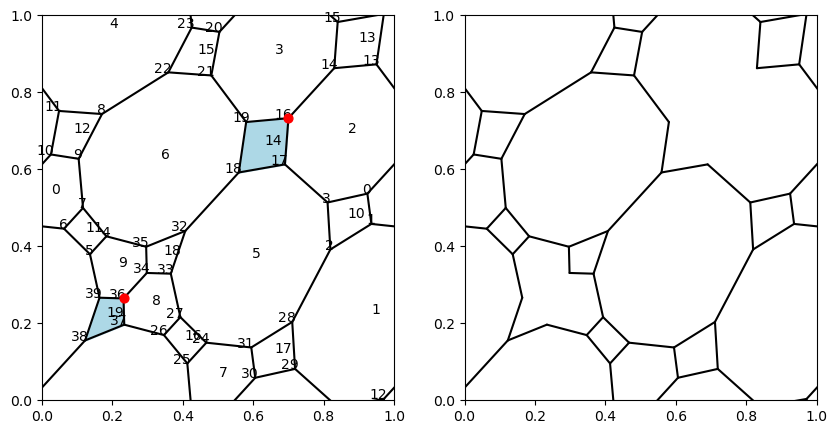

In [286]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))


reduced_lattice = gu.remove_vertices(lattice, chosen_vertices)

pl.plot_edges(lattice, ax=ax[0])
pl.plot_edges(reduced_lattice, ax=ax[1])
pl.plot_plaquettes(
    lattice, subset=chosen_plaquettes, zorder=-10, color_scheme=["lightblue"], ax=ax[0]
)

pl.plot_vertex_indices(lattice, ax=ax[0])
pl.plot_plaquette_indices(lattice, ax=ax[0])

chosen_positions = lattice.vertices.positions[chosen_vertices]
ax[0].scatter(*chosen_positions.T, zorder=10, c="r", s=40)

plt.show()

In [287]:
# brute force dimerisations
dimerisations = gu.dimerise(lattice, -1)
monomer_dimerisations = gu.dimerise(reduced_lattice, -1)
dimer_probabilities = np.average(dimerisations, axis=0)
dimer_dimer_probabilities = np.array(
    [dimer_dimer_prob(dimerisations, c) for c in randomly_chosen_edges]
)
n_dimerisations = dimerisations.shape[0]
n_monomer_dimerisations = monomer_dimerisations.shape[0]

print(f"n_dimers: {n_dimerisations}\n")
print(f"n_monomer_dimerisations: {n_monomer_dimerisations}\n")
print(f"monomer_probabilities: {n_monomer_dimerisations/n_dimerisations}\n")
print(f"dimer_probabilities\n{dimer_probabilities}\n")
print(f"dimer_dimer_probabilities\n{dimer_dimer_probabilities}\n")

n_dimers: 2895

n_monomer_dimerisations: 0

monomer_probabilities: 0.0

dimer_probabilities
[0.19896373 0.21727116 0.21243523 0.18134715 0.18134715 0.18134715
 0.19896373 0.16303972 0.15025907 0.19205527 0.19896373 0.19205527
 0.16303972 0.23385147 0.19205527 0.19205527 0.18134715 0.15025907
 0.19896373 0.21727116 0.40552677 0.3955095  0.44145078 0.37720207
 0.43005181 0.37789292 0.42314335 0.37789292 0.3955095  0.40552677
 0.37720207 0.44145078 0.42487047 0.39378238 0.39378238 0.42487047
 0.39378238 0.42487047 0.42487047 0.39378238 0.37720207 0.44145078
 0.3955095  0.40552677 0.42314335 0.37789292 0.43005181 0.37789292
 0.44145078 0.37720207 0.40552677 0.3955095  0.42487047 0.38307427
 0.38307427 0.42487047 0.38307427 0.42487047 0.42487047 0.38307427]

dimer_dimer_probabilities
[0.         0.0970639  0.05112263 0.         0.08048359 0.
 0.00379965 0.04352332 0.02279793 0.05492228]



First check that the number of dimerisations is right

In [288]:
# compute the four kasteleyn matrices
initial_ujk = ujk_from_fluxes(lattice, np.array([-1] * lattice.n_plaquettes))
orientations = generate_torus_orientations(lattice, initial_ujk)
kasteleyn_matrices = np.array([kasteleyn_matrix(lattice, o) for o in orientations])

# find inverses and pfaffians
inverses = np.array([la.inv(k) for k in kasteleyn_matrices])
pfaffians = np.array([fast_pfaffian_as_mpmath(k) for k in kasteleyn_matrices])


# find n_dimerisations from pfaffian
omega = find_omega(pfaffians)


n_dimerisations_pfaff = int(mpmath.nint(mpmath.fabs(sum(omega * pfaffians) / 2)))
print(n_dimerisations_pfaff)

assert (
    n_dimerisations - n_dimerisations_pfaff == 0
), f"{n_dimerisations - n_dimerisations_pfaff}"
print("counting dimerisations correctly")
# check its all correct
for j, k in enumerate(kasteleyn_matrices):
    assert np.all(k + k.T == 0)

2895
counting dimerisations correctly


In [289]:
# find probabilities per edge
inverse_numerator = np.sum(
    (omega * pfaffians)[:, None, None] * inverses * kasteleyn_matrices, axis=0
)
inverse_denominator = np.sum(omega * pfaffians)
probs_k = np.abs(
    (inverse_numerator / inverse_denominator)[*lattice.edges.indices.T]
).astype(float)


assert np.allclose(probs_k - dimer_probabilities, 0)
print("counting probabilities correctly")

counting probabilities correctly


In [290]:
multi_probabilities = []
for prob, edges in zip(dimer_dimer_probabilities, randomly_chosen_edges):

    verts = lattice.edges.indices[edges]
    kasteleyn_products = np.prod(kasteleyn_matrices[:, *verts.T], axis=1)

    slice = np.ix_(verts.flatten(), verts.flatten())
    inverse_chunk = inverses[:, *slice]
    pfaffians_chunk = np.array([fast_pfaffian_as_mpmath(k) for k in inverse_chunk])
    numerator = np.sum(omega * pfaffians * pfaffians_chunk * kasteleyn_products)

    multi_probabilities.append(np.abs(numerator / inverse_denominator))

assert np.allclose((multi_probabilities - dimer_dimer_probabilities).astype(float), 0)

print("counting dimer-dimer correlations correctly")

counting dimer-dimer correlations correctly


In [291]:
# compute the four kasteleyn matrices with monomer fluxes
monomer_fluxes = np.array([-1] * lattice.n_plaquettes)
monomer_fluxes[chosen_plaquettes] *= -1
monomer_ujk = ujk_from_fluxes(lattice, monomer_fluxes, initial_ujk)


monomer_orientations = generate_torus_orientations(lattice, monomer_ujk)
kasteleyn_tilde_matrices = np.array(
    [kasteleyn_matrix(lattice, o) for o in monomer_orientations]
)


pfaffians_tilde = []
inverses_tilde = []
for k in kasteleyn_tilde_matrices:
    p = fast_pfaffian_as_mpmath(k)
    if abs(p) > 1e-12:
        pfaffians_tilde.append(p)
        inverses_tilde.append(la.inv(k))
    else:
        pfaffians_tilde.append(0)
        inverses_tilde.append(np.zeros_like(k))

pfaffians_tilde = np.array(pfaffians_tilde)
inverses_tilde = np.array(inverses_tilde)

# find n_dimerisations from pfaffian

inverses_tilde_restricted = inverses_tilde[:, *np.ix_(chosen_vertices, chosen_vertices)]
inverses_tilde_pfaffs = np.array(
    [fast_pfaffian_as_mpmath(k) for k in inverses_tilde_restricted]
)
omega_tilde = find_omega(inverses_tilde_pfaffs * pfaffians_tilde)
monomer_numerator = omega_tilde * inverses_tilde_pfaffs * pfaffians_tilde
n_monomers_pfaff = int(mpmath.nint(mpmath.fabs(sum(monomer_numerator) / 2)))

if np.any(pfaffians_tilde == 0):
    print("one pfaffian vanishes")
    print(np.round(pfaffians_tilde.astype(int)))
print(n_monomers_pfaff, n_monomer_dimerisations, "\n\n")
try:
    assert (
        n_monomers_pfaff - n_monomer_dimerisations
    ) == 0, f"{n_monomers_pfaff - n_monomer_dimerisations}"

except AssertionError as e:
    omega_options = np.ones([4, 4]) - 2 * np.eye(4)
    for omega_tilde in omega_options:
        monomer_numerator = omega_tilde * inverses_tilde_pfaffs * pfaffians_tilde
        n_monomers_pfaff = int(mpmath.nint(mpmath.fabs(sum(monomer_numerator) / 2)))
        print(n_monomers_pfaff, n_monomer_dimerisations)

    assert False, f"{n_monomers_pfaff - n_monomer_dimerisations}"

print("counting monomers correctly")

0 0 


counting monomers correctly


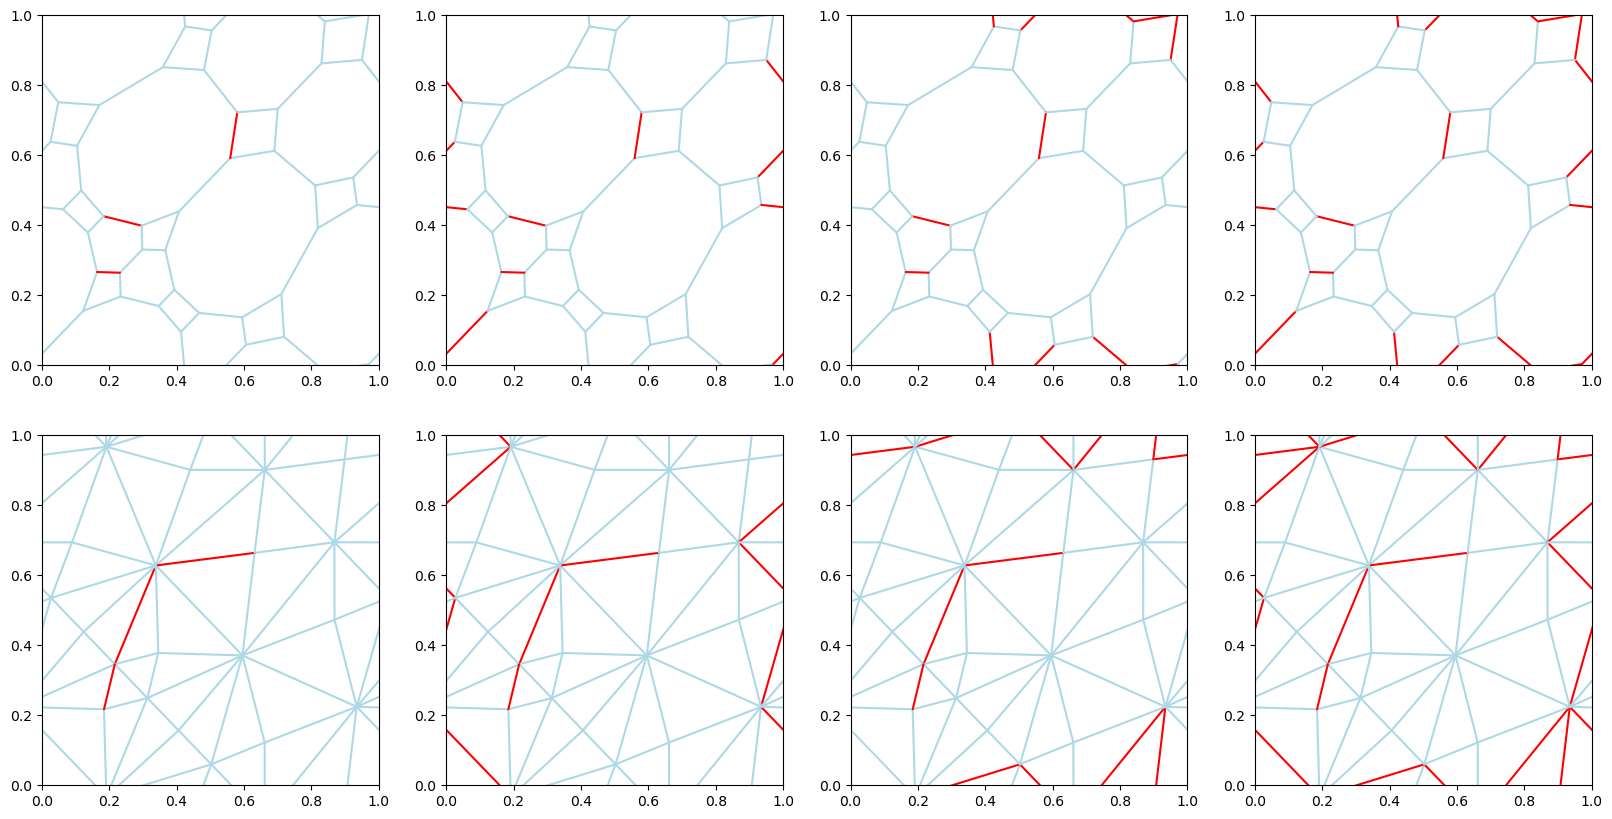

In [292]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))

for ii in range(4):

    ujk_diff = 1 - (monomer_orientations[ii] == initial_ujk)
    pl.plot_edges(
        lattice, ax=ax[0, ii], labels=ujk_diff, color_scheme=["lightblue", "red"]
    )
    pl.plot_edges(
        gu.make_dual(lattice, reg_steps=0),
        ax=ax[1, ii],
        labels=ujk_diff,
        color_scheme=["lightblue", "red"],
    )

In [293]:
del lattice